In [1]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data_path = './dataset/dataset/Training'

filepaths = []
label = []

folds = os.listdir(train_data_path)

for fold in folds:
    f_path = os.path.join(train_data_path, fold)
    if os.path.isdir(f_path):
        filelists = os.listdir(f_path)
        
        for file in filelists:
            filepaths.append(os.path.join(f_path, file))
            label.append(fold)

Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(label , name = 'label')
train_df = pd.concat([Fseries , Lseries] , axis = 1)

In [3]:
train_df

,filepaths,label
0,./dataset/dataset/Training\glioma\Tr-glTr_0000...,glioma
1,./dataset/dataset/Training\glioma\Tr-glTr_0001...,glioma
2,./dataset/dataset/Training\glioma\Tr-glTr_0002...,glioma
3,./dataset/dataset/Training\glioma\Tr-glTr_0003...,glioma
4,./dataset/dataset/Training\glioma\Tr-glTr_0004...,glioma
...,...,...
5707,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary
5708,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary
5709,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary
5710,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary


In [4]:
test_data_path = './dataset/dataset/Testing'

filepaths = []
label = []

folds = os.listdir(test_data_path)

for fold in folds:
    f_path = os.path.join(test_data_path, fold)
    if os.path.isdir(f_path):
        filelists = os.listdir(f_path)
        
        for file in filelists:
            filepaths.append(os.path.join(f_path, file))
            label.append(fold)

Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(label , name = 'label')
test_df = pd.concat([Fseries , Lseries] , axis = 1)

In [5]:
test_df

,filepaths,label
0,./dataset/dataset/Testing\glioma\Te-glTr_0000.jpg,glioma
1,./dataset/dataset/Testing\glioma\Te-glTr_0001.jpg,glioma
2,./dataset/dataset/Testing\glioma\Te-glTr_0002.jpg,glioma
3,./dataset/dataset/Testing\glioma\Te-glTr_0003.jpg,glioma
4,./dataset/dataset/Testing\glioma\Te-glTr_0004.jpg,glioma
...,...,...
1306,./dataset/dataset/Testing\pituitary\Te-pi_0295...,pituitary
1307,./dataset/dataset/Testing\pituitary\Te-pi_0296...,pituitary
1308,./dataset/dataset/Testing\pituitary\Te-pi_0297...,pituitary
1309,./dataset/dataset/Testing\pituitary\Te-pi_0298...,pituitary


### Data Spliting

In [6]:
valid, test = train_test_split(test_df , test_size = 0.5 , shuffle = True , random_state = 42)

In [7]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'label' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


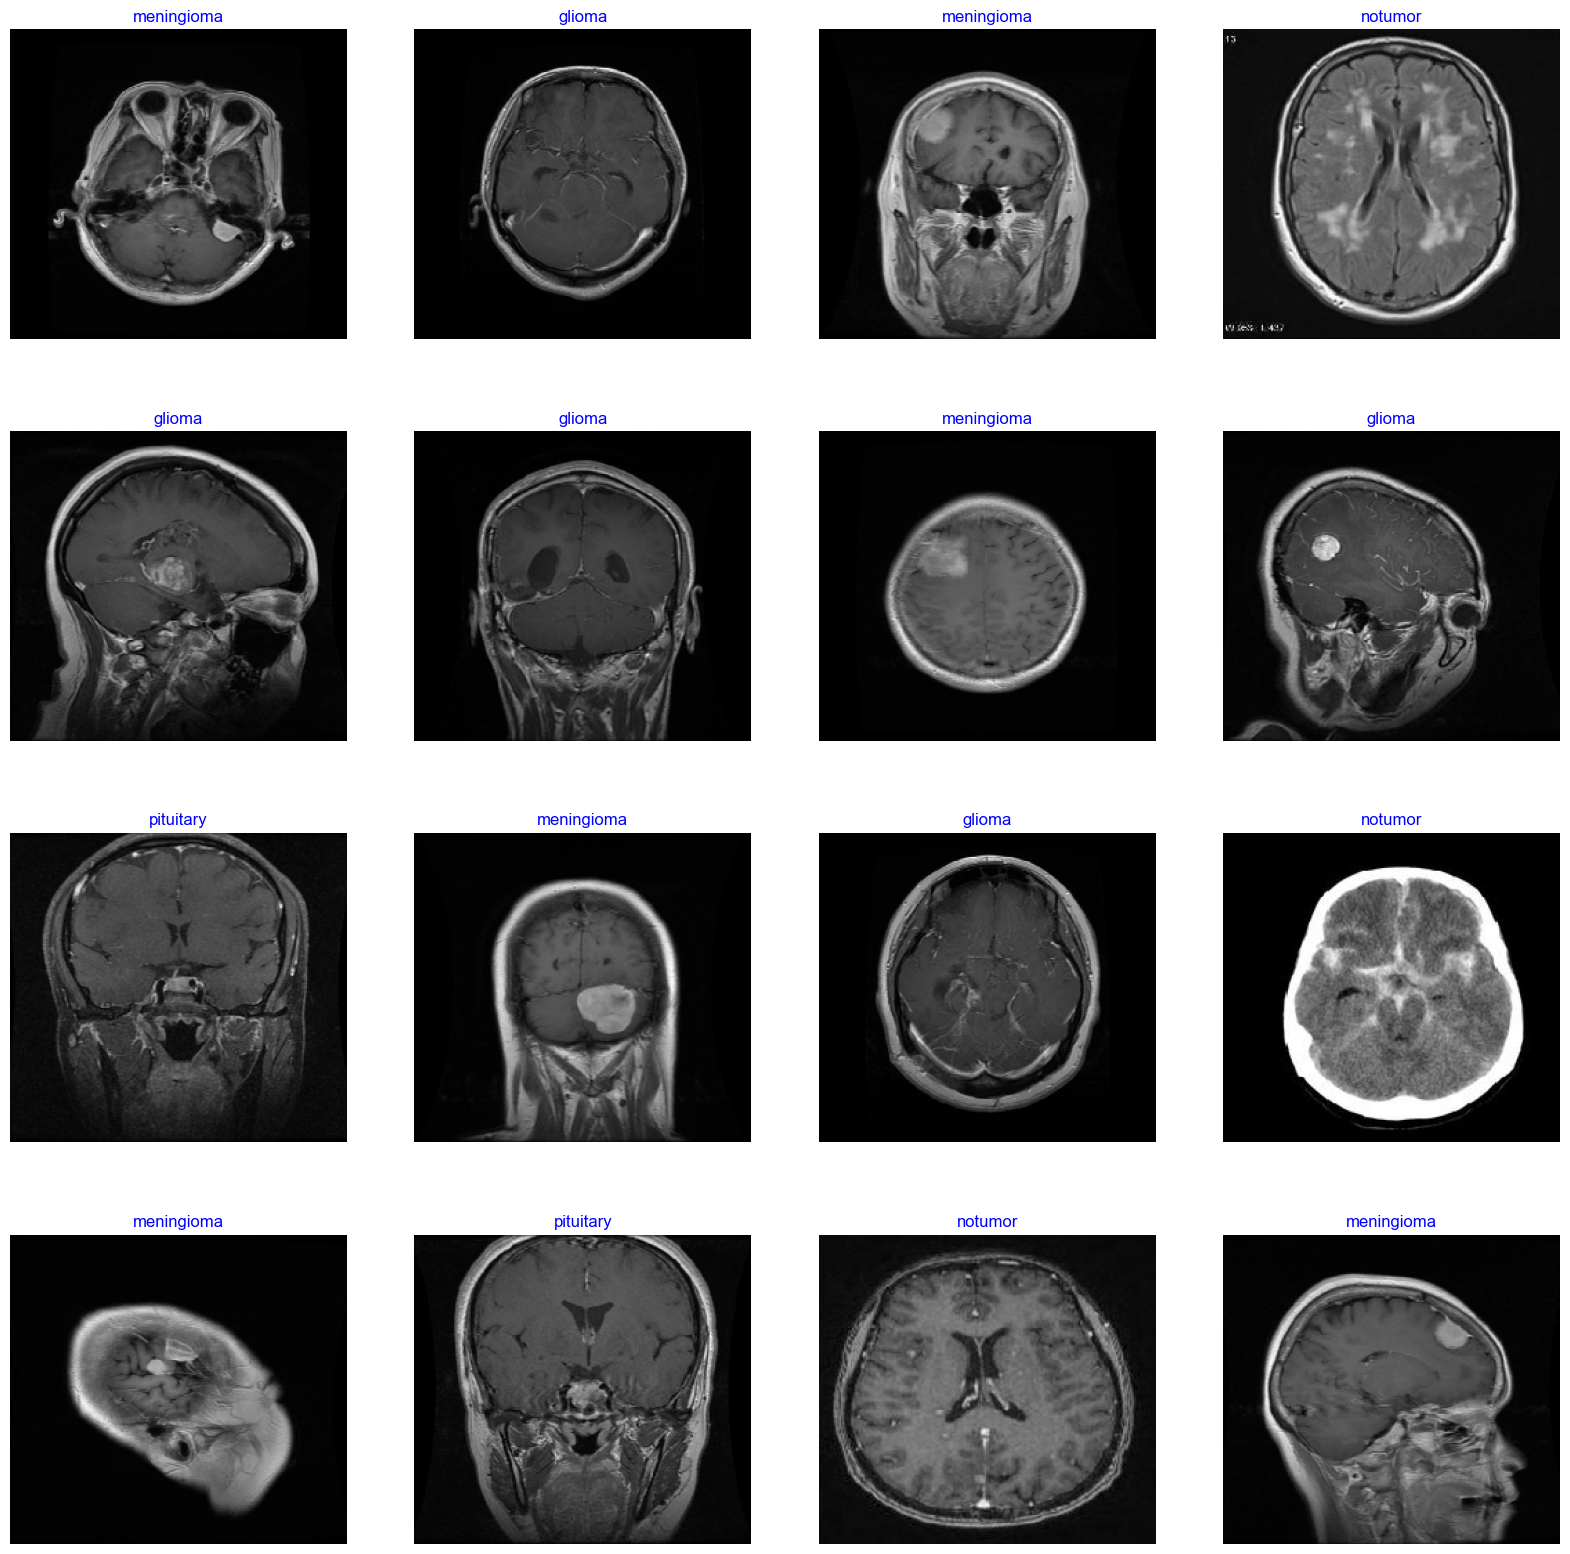

In [8]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images, labels = next(train_gen)
plt.figure(figsize = (20 , 20))
for i in range (16):
    plt.subplot(4 , 4 , i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color = 'blue' , fontsize = 12)
    plt.axis('off')
plt.show()

In [9]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [10]:
Epochs = 10

history = model.fit(
    train_gen ,
    validation_data = valid_gen,
    epochs = Epochs,
    shuffle = True,
    verbose = 1
)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.5002 - loss: 7.7604 - val_accuracy: 0.4626 - val_loss: 5.4474
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.4694 - loss: 4.4648 - val_accuracy: 0.6412 - val_loss: 3.5503
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.5919 - loss: 2.9466 - val_accuracy: 0.6992 - val_loss: 2.3302
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.6331 - loss: 2.0593 - val_accuracy: 0.7084 - val_loss: 1.7145
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.6647 - loss: 1.5518 - val_accuracy: 0.7374 - val_loss: 1.2316
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.7894 - loss: 1.2099 - val_accuracy: 0.9527 - val_loss: 0.9693
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.8922 - loss: 0.9702 - val_accuracy: 0.9725 - val_loss: 0.7358
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.8995 - loss: 0.8350 - val_accu

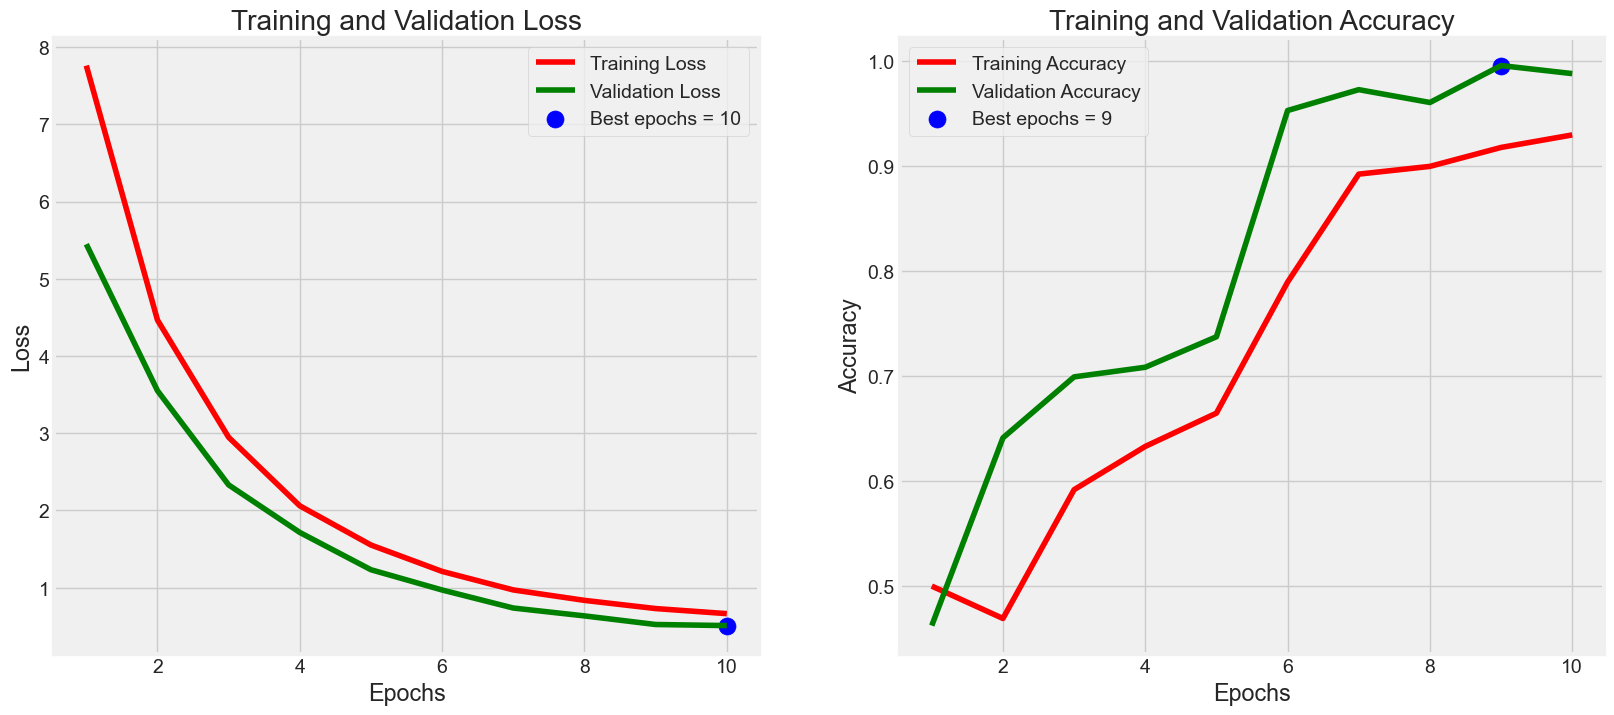

In [11]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show()

In [12]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.9922 - loss: 0.5119
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.9805 - loss: 0.5286
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - accuracy: 0.9766 - loss: 0.5402
Train Loss:  0.5118501782417297
Train Accuracy:  0.9921875
--------------------
Validation Loss:  0.5285987257957458
Validation Accuracy:  0.98046875
--------------------
Test Loss:  0.5401507616043091
Test Accuracy:  0.9765625


In [13]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 234ms/step


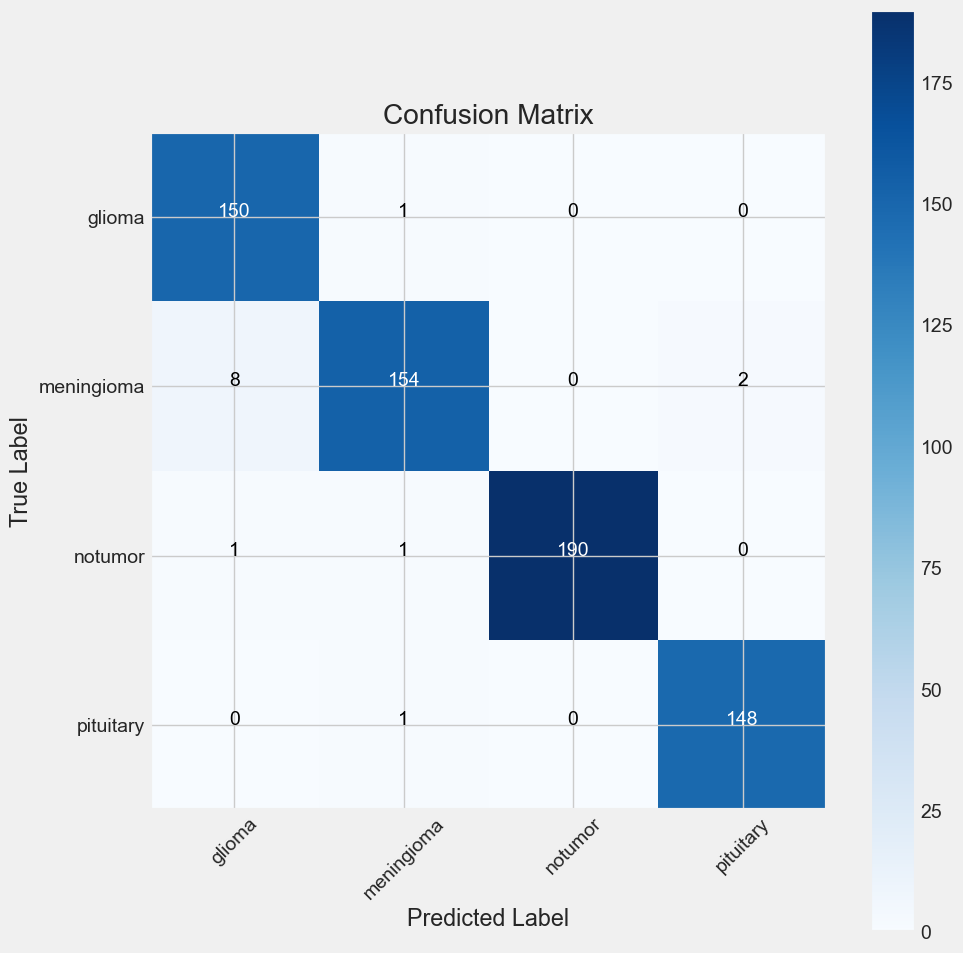

In [14]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [15]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       0.94      0.99      0.97       151
  meningioma       0.98      0.94      0.96       164
     notumor       1.00      0.99      0.99       192
   pituitary       0.99      0.99      0.99       149

    accuracy                           0.98       656
   macro avg       0.98      0.98      0.98       656
weighted avg       0.98      0.98      0.98       656



In [16]:
model.save("model.h5")

In [17]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

In [18]:
model = load_model('model.h5', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [19]:
gambar = tf.keras.preprocessing.image.load_img('./dataset/dataset/Testing/glioma/Te-glTr_0000.jpg', target_size=img_size)

In [20]:
input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

In [21]:
input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [22]:
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [23]:
names = [classes[i] for i in predicted_class]
print(names)

['glioma']


In [24]:
import tensorflow as tf
print("Available devices:")
for device in tf.config.list_physical_devices():
    print(device)

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


In [25]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0
